# ChestMNIST Weighted ANN with Cross-Validation on Colab

Self-contained notebook for ChestMNIST using a stronger ANN, weighted BCE, 3-fold cross-validation on the official train split, test evaluation once at the end, Drive saving, and a download cell.

In [1]:
import os
from pathlib import Path

IN_COLAB = 'COLAB_GPU' in os.environ
save_root = Path('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    preferred_roots = [
        Path('/content/drive/MyDrive/Colab Experiments/Lab3-LT'),
        Path('/content/drive/MyDrive/Lab3-LT'),
        Path('/content/drive/MyDrive/Colab Notebooks/Lab3-LT'),
    ]
    for candidate in preferred_roots:
        candidate.mkdir(parents=True, exist_ok=True)
        save_root = candidate
        break

artifact_dir = save_root / 'artifacts' / 'chestmnist_weighted_cv_ann'
data_root = save_root / 'data' / 'chestmnist'
artifact_dir.mkdir(parents=True, exist_ok=True)
data_root.mkdir(parents=True, exist_ok=True)

print('save_root =', save_root)
print('artifact_dir =', artifact_dir)
print('data_root =', data_root)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
save_root = /content/drive/MyDrive/Colab Experiments/Lab3-LT
artifact_dir = /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_weighted_cv_ann
data_root = /content/drive/MyDrive/Colab Experiments/Lab3-LT/data/chestmnist


In [2]:
if IN_COLAB:
    !pip install -q medmnist scikit-learn matplotlib iterative-stratification
    !nvidia-smi


Thu Mar 26 07:56:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P0             28W /   70W |     187MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import json
import math
import random
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import medmnist
import numpy as np
import torch
import torch.nn as nn
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from medmnist import INFO
from sklearn.metrics import f1_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset

SEED = 42
NUM_FOLDS = 3
EPOCHS = 25
BATCH_SIZE = 512
LR = 1e-3
WEIGHT_DECAY = 1e-4
THRESHOLD_GRID = np.linspace(0.05, 0.50, 10)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

class ChestMnistRawDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray) -> None:
        self.images = images.astype(np.float32) / 255.0
        self.labels = labels.astype(np.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        image = self.images[idx].reshape(-1)
        label = self.labels[idx]
        return torch.from_numpy(image).float(), torch.from_numpy(label).float()

class ChestWeightedAnn(nn.Module):
    def __init__(self, input_dim: int = 784, num_classes: int = 14) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.net(x)

@dataclass
class EvalResult:
    loss: float
    macro_auc: float
    macro_f1: float
    y_true: np.ndarray
    y_prob: np.ndarray

def safe_macro_auc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    aucs = []
    for i in range(y_true.shape[1]):
        col = y_true[:, i]
        if np.unique(col).size < 2:
            continue
        aucs.append(roc_auc_score(col, y_prob[:, i]))
    return float(np.mean(aucs)) if aucs else 0.0

def macro_f1_with_thresholds(y_true: np.ndarray, y_prob: np.ndarray, thresholds: np.ndarray) -> float:
    y_pred = (y_prob >= thresholds[None, :]).astype(np.float32)
    f1s = []
    for i in range(y_true.shape[1]):
        f1s.append(f1_score(y_true[:, i], y_pred[:, i], zero_division=0))
    return float(np.mean(f1s))

def evaluate(model, loader, criterion, thresholds=None):
    model.eval()
    total_loss = 0.0
    total_items = 0
    all_true = []
    all_prob = []
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            logits = model(features)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            total_loss += loss.item() * features.size(0)
            total_items += features.size(0)
            all_true.append(labels.cpu().numpy())
            all_prob.append(probs.cpu().numpy())
    y_true = np.concatenate(all_true, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)
    macro_auc = safe_macro_auc(y_true, y_prob)
    if thresholds is None:
        thresholds = np.full(y_true.shape[1], 0.5, dtype=np.float32)
    macro_f1 = macro_f1_with_thresholds(y_true, y_prob, thresholds)
    return EvalResult(total_loss / max(total_items, 1), macro_auc, macro_f1, y_true, y_prob)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_items = 0
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * features.size(0)
        total_items += features.size(0)
    return total_loss / max(total_items, 1)

def tune_thresholds(y_true: np.ndarray, y_prob: np.ndarray) -> np.ndarray:
    thresholds = []
    for i in range(y_true.shape[1]):
        best_t = 0.5
        best_f1 = -1.0
        for t in THRESHOLD_GRID:
            pred = (y_prob[:, i] >= t).astype(np.float32)
            score = f1_score(y_true[:, i], pred, zero_division=0)
            if score > best_f1:
                best_f1 = score
                best_t = float(t)
        thresholds.append(best_t)
    return np.asarray(thresholds, dtype=np.float32)


device = cuda


In [4]:
info = INFO['chestmnist']
DataClass = getattr(medmnist, info['python_class'])

train_set = DataClass(split='train', download=True, root=str(data_root), size=28)
test_set = DataClass(split='test', download=True, root=str(data_root), size=28)

train_images = train_set.imgs
train_labels = train_set.labels.astype(np.float32)
test_images = test_set.imgs
test_labels = test_set.labels.astype(np.float32)

class_names = info['label']
print('train_images =', train_images.shape)
print('test_images =', test_images.shape)
print('num_classes =', len(class_names))


train_images = (78468, 28, 28)
test_images = (22433, 28, 28)
num_classes = 14



===== Fold 1/3 =====
{"epoch": 1, "train_loss": 1.2627658527694834, "train_macro_auc": 0.6816763614080658, "train_macro_f1_at_0_5": 0.1301204051045726, "val_loss": 1.2278549926582507, "val_macro_auc": 0.6690539330478639, "val_macro_f1_at_0_5": 0.1283166056168982}
{"epoch": 2, "train_loss": 1.2063751309121087, "train_macro_auc": 0.698348669555508, "train_macro_f1_at_0_5": 0.1258895561122781, "val_loss": 1.2378077151706448, "val_macro_auc": 0.6810882298664989, "val_macro_f1_at_0_5": 0.12457240259715545}
{"epoch": 3, "train_loss": 1.176983377404453, "train_macro_auc": 0.7183183239132834, "train_macro_f1_at_0_5": 0.14629678997780135, "val_loss": 1.24352983998895, "val_macro_auc": 0.6932159814011946, "val_macro_f1_at_0_5": 0.14264262898972177}
{"epoch": 4, "train_loss": 1.1590763950661465, "train_macro_auc": 0.7302755665531695, "train_macro_f1_at_0_5": 0.15020171883429737, "val_loss": 1.1910488521821236, "val_macro_auc": 0.7049757191145287, "val_macro_f1_at_0_5": 0.14621011275307458}
{"epo

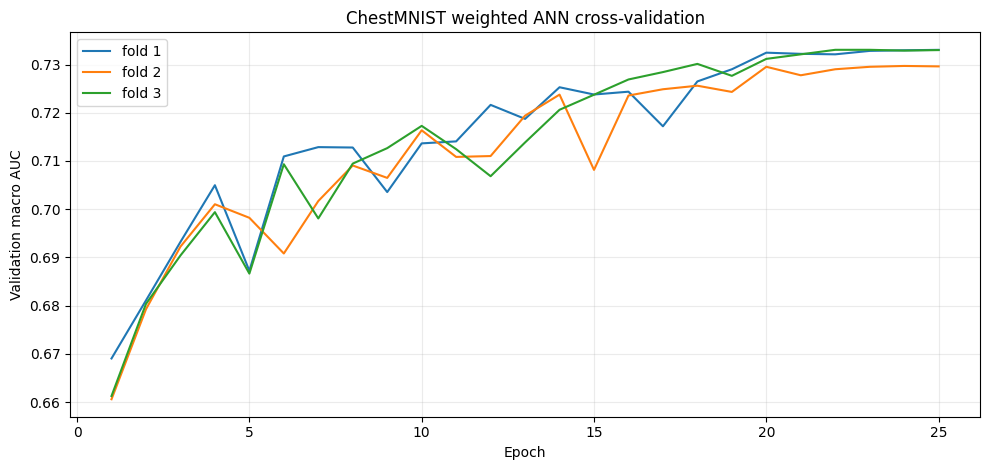

{
  "ensemble_test_macro_auc": 0.7305706907149164,
  "ensemble_test_macro_f1_tuned": 0.16045755724532906,
  "artifact_dir": "/content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_weighted_cv_ann"
}


In [5]:
mskf = MultilabelStratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
test_loader = DataLoader(ChestMnistRawDataset(test_images, test_labels), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

fold_summaries = []
fold_histories = []
fold_thresholds = []
fold_test_prob = []
saved_models = []

for fold_idx, (subtrain_idx, val_idx) in enumerate(mskf.split(train_images, train_labels), start=1):
    print(f'\n===== Fold {fold_idx}/{NUM_FOLDS} =====')
    subtrain_images = train_images[subtrain_idx]
    subtrain_labels = train_labels[subtrain_idx]
    val_images = train_images[val_idx]
    val_labels = train_labels[val_idx]

    positives = subtrain_labels.sum(axis=0)
    negatives = len(subtrain_labels) - positives
    pos_weight = (negatives / np.clip(positives, 1.0, None)).astype(np.float32)

    train_loader = DataLoader(ChestMnistRawDataset(subtrain_images, subtrain_labels), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(ChestMnistRawDataset(val_images, val_labels), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = ChestWeightedAnn(num_classes=len(class_names)).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_auc = -1.0
    best_state = None
    history = []

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        train_eval = evaluate(model, train_loader, criterion)
        val_eval = evaluate(model, val_loader, criterion)
        scheduler.step()

        row = {
            'epoch': epoch,
            'train_loss': float(train_loss),
            'train_macro_auc': train_eval.macro_auc,
            'train_macro_f1_at_0_5': train_eval.macro_f1,
            'val_loss': val_eval.loss,
            'val_macro_auc': val_eval.macro_auc,
            'val_macro_f1_at_0_5': val_eval.macro_f1,
        }
        history.append(row)
        print(json.dumps(row))

        if val_eval.macro_auc > best_val_auc:
            best_val_auc = val_eval.macro_auc
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    best_val_eval = evaluate(model, val_loader, criterion)
    thresholds = tune_thresholds(best_val_eval.y_true, best_val_eval.y_prob)
    tuned_val_f1 = macro_f1_with_thresholds(best_val_eval.y_true, best_val_eval.y_prob, thresholds)
    test_eval = evaluate(model, test_loader, criterion, thresholds)

    fold_dir = artifact_dir / f'fold_{fold_idx}'
    fold_dir.mkdir(parents=True, exist_ok=True)
    torch.save({
        'model_state_dict': best_state,
        'thresholds': thresholds,
        'pos_weight': pos_weight,
        'best_val_macro_auc': best_val_auc,
    }, fold_dir / 'model_best.pt')
    (fold_dir / 'history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')

    summary = {
        'fold': fold_idx,
        'best_val_macro_auc': best_val_auc,
        'best_val_macro_f1_at_0_5': best_val_eval.macro_f1,
        'best_val_macro_f1_tuned': tuned_val_f1,
        'test_macro_auc': test_eval.macro_auc,
        'test_macro_f1_tuned': test_eval.macro_f1,
    }
    fold_summaries.append(summary)
    fold_histories.append(history)
    fold_thresholds.append(thresholds)
    fold_test_prob.append(test_eval.y_prob)
    saved_models.append(str(fold_dir / 'model_best.pt'))
    print('fold_summary =', json.dumps(summary, indent=2))

ensemble_prob = np.mean(np.stack(fold_test_prob, axis=0), axis=0)
ensemble_thresholds = np.mean(np.stack(fold_thresholds, axis=0), axis=0)
ensemble_auc = safe_macro_auc(test_labels, ensemble_prob)
ensemble_f1 = macro_f1_with_thresholds(test_labels, ensemble_prob, ensemble_thresholds)

metrics = {
    'dataset': 'chestmnist',
    'architecture': 'raw flatten -> 1024 -> 512 -> 256 -> 14 with BatchNorm + ReLU + Dropout',
    'num_folds': NUM_FOLDS,
    'epochs_per_fold': EPOCHS,
    'batch_size': BATCH_SIZE,
    'optimizer': 'AdamW',
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'criterion': 'BCEWithLogitsLoss(pos_weight)',
    'class_names': class_names,
    'fold_summaries': fold_summaries,
    'ensemble_test_macro_auc': ensemble_auc,
    'ensemble_test_macro_f1_tuned': ensemble_f1,
    'ensemble_thresholds': ensemble_thresholds.tolist(),
    'saved_models': saved_models,
}

(artifact_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
np.save(artifact_dir / 'test_y_true.npy', test_labels)
np.save(artifact_dir / 'ensemble_test_y_prob.npy', ensemble_prob)
np.save(artifact_dir / 'ensemble_thresholds.npy', ensemble_thresholds)
np.save(artifact_dir / 'fold_thresholds.npy', np.stack(fold_thresholds, axis=0))

plt.figure(figsize=(10, 4.8))
for fold_idx, history in enumerate(fold_histories, start=1):
    epochs = [row['epoch'] for row in history]
    val_auc = [row['val_macro_auc'] for row in history]
    plt.plot(epochs, val_auc, label=f'fold {fold_idx}')
plt.xlabel('Epoch')
plt.ylabel('Validation macro AUC')
plt.title('ChestMNIST weighted ANN cross-validation')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(artifact_dir / 'cv_val_auc_curves.png', dpi=200, bbox_inches='tight')
plt.show()

print(json.dumps({
    'ensemble_test_macro_auc': ensemble_auc,
    'ensemble_test_macro_f1_tuned': ensemble_f1,
    'artifact_dir': str(artifact_dir),
}, indent=2))


In [6]:
import json
metrics = json.loads((artifact_dir / 'metrics.json').read_text(encoding='utf-8'))
print('ensemble_test_macro_auc =', metrics['ensemble_test_macro_auc'])
print('ensemble_test_macro_f1_tuned =', metrics['ensemble_test_macro_f1_tuned'])
print('saved_models =')
for item in metrics['saved_models']:
    print('-', item)
print('\nFiles in artifact_dir:')
for p in sorted(artifact_dir.glob('*')):
    print('-', p.name)


ensemble_test_macro_auc = 0.7305706907149164
ensemble_test_macro_f1_tuned = 0.16045755724532906
saved_models =
- /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_weighted_cv_ann/fold_1/model_best.pt
- /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_weighted_cv_ann/fold_2/model_best.pt
- /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_weighted_cv_ann/fold_3/model_best.pt

Files in artifact_dir:
- cv_val_auc_curves.png
- ensemble_test_y_prob.npy
- ensemble_thresholds.npy
- fold_1
- fold_2
- fold_3
- fold_thresholds.npy
- metrics.json
- test_y_true.npy


In [7]:
import shutil
zip_base = artifact_dir.parent / artifact_dir.name
zip_path = shutil.make_archive(str(zip_base), 'zip', root_dir=str(artifact_dir))
print('zip_path =', zip_path)
if IN_COLAB:
    from google.colab import files
    files.download(zip_path)


zip_path = /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_weighted_cv_ann.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>